## IMPORTS

In [63]:
from IPython.display import display

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from gerrychain import (Partition, Graph, updaters, MarkovChain, constraints, accept)
from gerrychain.proposals import recom
from gerrychain.constraints import contiguous
from gerrychain.updaters import cut_edges
from gerrychain.tree import recursive_tree_part
from functools import partial

MARKOV_STEPS = 250_000
DESIRED_TCP = 0.8

## READING FILES

In [64]:
#from 2020 general election (3215 vtds)
vtds = gpd.read_file("co_2020/co_2020.shp")
#from representable (338 COIS)
cois = gpd.read_file("Colorado_communities.geojson")
#congressional map
congressional_2021 = gpd.read_file("2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_with_Final_Adjustments/2021_Approved_Congressional_Plan_w_Final_Adjustments.shp")

## PLOTTING

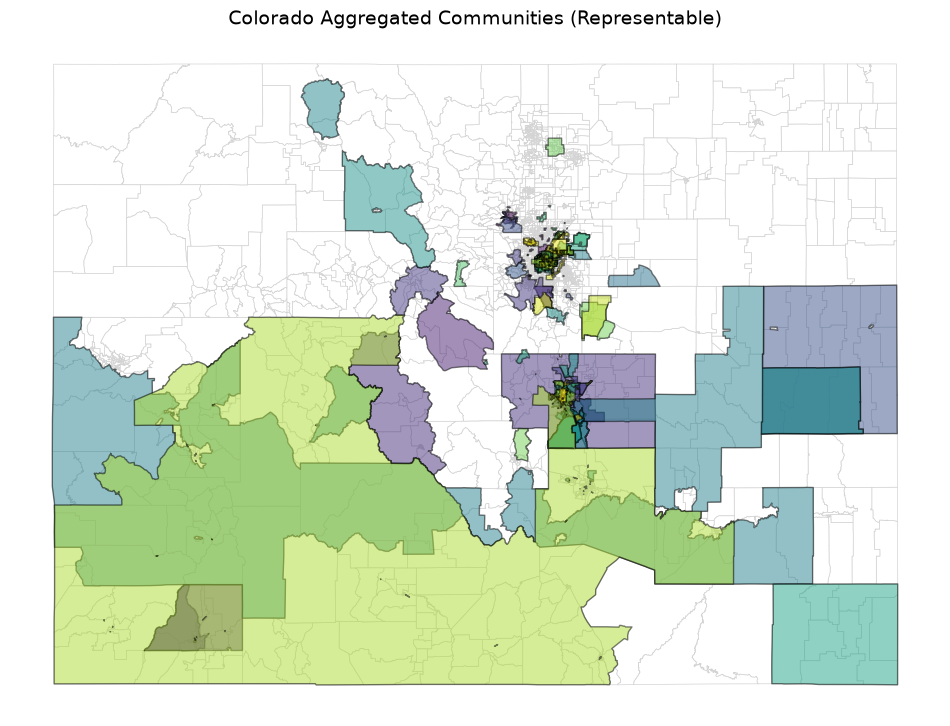

"\ncois['shape_size'] = cois.area\ncois_sorted = cois.sort_values(by='shape_size', ascending = False)\n\nfor i in len(cois_sorted):\n\n    single_coi = cois_sorted.iloc[[i]]\n    fig, ax = plt.subplots(figsize=(8, 8))\n\n    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')\n    plt.title(single_coi.entry_name)\n\nplt.show()\n"

In [65]:

fig, ax = plt.subplots(figsize=(12, 10))

vtds.plot(ax=ax, color="white", edgecolor="lightgray", linewidth=0.5)
cois.plot(ax=ax, cmap = "viridis", alpha=0.5, edgecolor="black")

ax.set_title("Colorado Aggregated Communities (Representable)", fontsize=14)
ax.axis("off")
plt.show()

#if you ever wanted to print individual cois by area
'''
cois['shape_size'] = cois.area
cois_sorted = cois.sort_values(by='shape_size', ascending = False)

for i in len(cois_sorted):

    single_coi = cois_sorted.iloc[[i]]
    fig, ax = plt.subplots(figsize=(8, 8))

    single_coi.plot(ax=ax, facecolor='skyblue', edgecolor='black')
    plt.title(single_coi.entry_name)

plt.show()
'''

In [66]:
#if cois.crs != vtds.crs:
    #vtds = vtds.to_crs(cois.crs)

pres_cols = ['G20PREDBID', 'G20PRERTRU', 'G20PRECBLA', 'G20PRELJOR', 'G20PREGHAW', 'G20PREUWES', 'G20PREOOTH']
vtds['TOTPOP'] = vtds[pres_cols].sum(axis=1)


vtds['vtd_area'] = vtds.geometry.area
overlaps = gpd.overlay(vtds, cois, how='intersection')
overlaps['coi_fraction'] = overlaps.geometry.area / overlaps['vtd_area']

clean_overlaps = overlaps[overlaps['coi_fraction'] > 0.01].copy()

clean_overlaps['coi_pop'] = clean_overlaps['TOTPOP'] * clean_overlaps['coi_fraction']

coi_dict = {}
for index, row in clean_overlaps.iterrows():
    vtd_name = row['NAME']
    cluster_id = row['entry_ID']
    population_chunk = row['coi_pop']
    
    if vtd_name not in coi_dict:
        coi_dict[vtd_name] = {}
        
    coi_dict[vtd_name][cluster_id] = population_chunk


vtds['COI_POPS'] = [coi_dict.get(name, {}) for name in vtds['NAME']]

C:\Users\noede\AppData\Local\Temp\ipykernel_27452\83098508.py:8: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  vtds['vtd_area'] = vtds.geometry.area
C:\Users\noede\AppData\Local\Temp\ipykernel_27452\83098508.py:9: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4269
Right CRS: EPSG:4326

  overlaps = gpd.overlay(vtds, cois, how='intersection')
c:\Users\noede\OneDrive\Desktop\CS\MCURE\.venv\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 41 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)
C:\Users\noede\AppData\

## 2021 CO Congressional Map Cleanup

In [67]:

congressional_2021 = congressional_2021.to_crs(vtds.crs)

# get center vtd points to map to congressional districts
vtd_points = vtds.copy()
vtd_points.geometry = vtd_points.representative_point()

joined_vtds_2021 = gpd.sjoin(vtd_points, congressional_2021, how="left", predicate="intersects")

vtds['district_2021'] = joined_vtds_2021['District']

## DEUBGGING

In [68]:
#display(vtds[['NAME', 'TOTPOP', 'COI_POPS']].head(100))
#print(vtds)

## HELPER FUNCTIONS

In [69]:
def extract_data(partition):
    data_rows = []

    for node_id in partition.graph.nodes:
        assigned_dist = partition.assignment[node_id]
        # grab the dict with community pop info
        node_cois = partition.graph.nodes[node_id].get("COI_POPS", {})
        for coi_id, coi_pop in node_cois.items():
            data_rows.append(
                {
                    #TODO: no categories for this data so just 1 'coi' bucket, maybe NLP will give us categories later
                    "category": "coi",
                    "community_id": coi_id,
                    "district": assigned_dist,
                    "pop": coi_pop,
                }
            )

    return pd.DataFrame(data_rows)

def plot_partition(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    
    vtds.plot(ax=ax, column="district", cmap='Pastel1',edgecolor="black", linewidth=0.15)
    #cois.plot(ax=ax, column="cluster", facecolor='none', edgecolor="red", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

def plot_partition_party(partition, vtds, cois, title):
    # map districts to df
    vtds['district'] = vtds.index.map(partition.assignment)
    
    district_colors = {}
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            dem_pop += partition.graph.nodes[node_id]['G20PREDBID']
            tot_pop += partition.graph.nodes[node_id]['TOTPOP']
            
        if tot_pop > 0 and (dem_pop / tot_pop) > 0.5:
            district_colors[district_id] = "lightblue"
        else:
            district_colors[district_id] = "lightcoral"
            

    vtds['party_color'] = vtds['district'].map(district_colors)
    
    fig, ax = plt.subplots(figsize=(12, 10))

    partition.plot(ax=ax, edgecolor = "black", linewidth = 2)
    vtds.plot(ax=ax, color=vtds['party_color'], edgecolor="black", linewidth=0.15)

    if title:
        ax.set_title(title, fontsize=16)
    ax.axis("off")
    plt.show()

## SCORING FUNCTIONS

In [70]:
def score_communities(unscored_df):
    """
    calculates the sum of squared shares for each community

    inputs:
        unscored_df: df with cols: category, community_id, district, pop
    outputs:
        communities_scores: df with cols: category, community_id, total_pop, sss_score
    """
    # get total pop per community (water1, water2..)
    total_pops = unscored_df.groupby(['category', 'community_id'])['pop'].sum().reset_index()
    total_pops.rename(columns={'pop': 'total_pop'}, inplace=True)

    # get pop per community and district
    district_splits = unscored_df.groupby(['category', 'community_id', 'district'])['pop'].sum().reset_index()

    # merge to get pop / total pop
    merged = pd.merge(district_splits, total_pops, on=['category', 'community_id'])

    # get squared shares
    merged['share'] = merged['pop'] / merged['total_pop']
    merged['squared_share'] = merged['share'] ** 2

    # sum squared shares across all communities in each category
    # this is the 'final' score for each community (not grouped yet)
    final_sss_df = merged.groupby(['category', 'community_id', 'total_pop'])['squared_share'].sum().reset_index()
    final_sss_df.rename(columns={'squared_share': 'sss_score'}, inplace=True)
    return final_sss_df

def score_overall(dataframe, weights):
    """
    calculates the total coi preservation as a single metric between 0 and 1

    inputs:
        dataframe: output from score_communities()
        weights: dict with keys: category, values: weight
    outputs:
        final_score: total coi preservation (tcp) between 0 and 1
    """
    # after getting sss score for each community, we want 1 final metric
    # bigger populations need more weight in category averages
    # get pop weighted avg for each community - sum(pop[i] * coi score / category pop
    dataframe['weighted_score'] = dataframe['sss_score'] * dataframe['total_pop']
    category_score_sums = dataframe.groupby('category')['weighted_score'].sum()
    category_pop_sums = dataframe.groupby('category')['total_pop'].sum()

    # gets our category averages
    pop_weighted_avg = category_score_sums / category_pop_sums
    # multiply each category score by weight and sum for final metric
    final_score = (pop_weighted_avg * pd.Series(weights)).sum()
    return final_score

def calculate_tcp(partition):
    # arbitrary
    #weights = {'water': 0.5, 'county': 0.3, 'muni': 0.2}
    # TODO: get NLP to categorize and weight
    weights = {'coi': 1}

    raw_df = extract_data(partition)
    community_scores = score_communities(raw_df)
    final_score = score_overall(community_scores, weights)
    
    return final_score

def count_dem_wins(partition):
    dem_wins = 0
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        if dem_pop / tot_pop > 0.5:
            dem_wins += 1

    return dem_wins

def dem_share(partition):
    dem_shares = []
    for district_id, node_ids in partition.parts.items():
        dem_pop = 0
        tot_pop = 0
        for node_id in node_ids:
            # grab node info
            node_attrs = partition.graph.nodes[node_id]
            # get vote pop and total pop
            dem_pop += node_attrs['G20PREDBID']
            tot_pop += node_attrs['TOTPOP']
            
        dem_share = dem_pop / tot_pop if tot_pop > 0 else 0
        dem_shares.append(dem_share)
        
    dem_shares.sort()
    return tuple(dem_shares)



## INIT GRAPH AND CHAIN

In [71]:
from gerrychain.accept import always_accept
## init graph
vtds.geometry = vtds.geometry.buffer(0)
g = Graph.from_geodataframe(vtds)

# Colorado has 8 districts
total_population = sum(node.get('TOTPOP', 1) for node in g.nodes.values())
target_pop = total_population / 8

# using a gerrychain method to start with 8 equal nice contiguous parts
starting_assignment = recursive_tree_part(
    g, 
    parts=range(8), 
    pop_target=target_pop, 
    pop_col="TOTPOP", 
    epsilon=0.05
)

## init part
initial_partition = Partition(
    g, 
    assignment=starting_assignment, 
    updaters={ 
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins,
        'dem_share': dem_share
    }
)

## init chain
proposal = partial(recom, pop_col="TOTPOP", pop_target=target_pop, epsilon=0.05, node_repeats=2)
chain = MarkovChain(
    proposal=proposal,
    constraints=[contiguous],
    accept=always_accept,
    initial_state=initial_partition,
    total_steps=MARKOV_STEPS
)

c:\Users\noede\OneDrive\Desktop\CS\MCURE\.venv\Lib\site-packages\gerrychain\graph\adjacency.py:112: UserWarning: Found overlaps among the given polygons. Indices of overlaps: {(1265, 1321), (1218, 3195), (1277, 1295), (536, 537), (1129, 1131), (40, 41), (2652, 2864), (1842, 1845), (2510, 2551), (2397, 2494), (590, 593), (2254, 2445), (1840, 3214), (2365, 2443), (1460, 2584), (110, 123), (200, 1118), (107, 234), (548, 632), (1713, 1717), (1295, 1339), (2639, 2786), (1866, 2570), (620, 2332), (869, 2008), (2612, 2786), (241, 2012), (633, 3192), (238, 2025), (2650, 2651), (3179, 3180), (3212, 3214), (2750, 2774), (1554, 1558), (22, 23), (1282, 1364), (514, 589), (1113, 1177), (1464, 1502), (1954, 2449), (2517, 2526), (2713, 2748), (585, 649), (1218, 2938), (2935, 3188), (2937, 3130), (2698, 2705), (205, 2332), (486, 508), (1576, 1581), (2566, 2567), (2628, 2640), (2425, 3202), (80, 85), (2325, 2477), (2679, 2709), (1215, 3152), (1370, 3193), (2934, 2935), (1493, 2589), (1912, 1935), (2649

## RUN CHAIN

In [72]:
# collect scores
tcp_scores = []
cut_edges_count = []
dem_wins_count = []

# dem shares init
dist_1_shares = []
dist_2_shares = []
dist_3_shares = []
dist_4_shares = []
dist_5_shares = []
dist_6_shares = []
dist_7_shares = []
dist_8_shares = []

# maps score
best_score=0
best_map=None
worst_score=1
worst_map=None
overall_best_score=0
overall_best_map=None
most_seats=0

# all tcp scores grouped by seat count
tcp_scores_by_seats = {seat_count: [] for seat_count in range(9)}

for partition in chain:
    # track every 50k steps
    if len(tcp_scores) > 0 and len(tcp_scores) % 50000 == 0:
        print(f"completed {len(tcp_scores)} steps...")

    score = partition['tcp_score']
    cuts = len(partition['cut_edges'])
    seats = partition['dem_wins']
    shares = partition['dem_share']

    tcp_scores.append(score)
    cut_edges_count.append(cuts)
    dem_wins_count.append(seats)

    dist_1_shares.append(shares[0])
    dist_2_shares.append(shares[1])
    dist_3_shares.append(shares[2])
    dist_4_shares.append(shares[3])
    dist_5_shares.append(shares[4])
    dist_6_shares.append(shares[5])
    dist_7_shares.append(shares[6])
    dist_8_shares.append(shares[7])

    # append scores under its seat count 
    tcp_scores_by_seats[seats].append(score)

    # track most preserved
    if score > best_score:
        best_score = score
        best_map = partition

    # track least preserved
    if score < worst_score:
        worst_score = score
        worst_map = partition

    # track max minority seats, best score
    if seats > most_seats:
        most_seats = seats
        overall_best_score = score
        overall_best_map = partition
    elif seats == most_seats:
        if score > overall_best_score:
            overall_best_score = score
            overall_best_map = partition

# save to csv
chain_results = {
    'step': range(len(tcp_scores)),
    'tcp_score': tcp_scores,
    'cut_edges': cut_edges_count,
    'dem_wins': dem_wins_count,
    'dist_1_dem_share': dist_1_shares,
    'dist_2_dem_share': dist_2_shares,
    'dist_3_dem_share': dist_3_shares,
    'dist_4_dem_share': dist_4_shares,
    'dist_5_dem_share': dist_5_shares,
    'dist_6_dem_share': dist_6_shares,
    'dist_7_dem_share': dist_7_shares,
    'dist_8_dem_share': dist_8_shares
}

#results_df = pd.DataFrame(chain_results)
#results_df.to_csv("data/colorado_neutral_500k.csv", index=False)

c:\Users\noede\OneDrive\Desktop\CS\MCURE\.venv\Lib\site-packages\gerrychain\tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(


completed 50000 steps...
completed 100000 steps...
completed 150000 steps...
completed 200000 steps...


## ENACTED PARTITION

In [73]:
enacted_2021 = Partition(
    g,
    assignment="district_2021",
    updaters={
        'tcp_score': calculate_tcp,
        'cut_edges': cut_edges,
        'dem_wins': count_dem_wins
    }
)

## HISTOGRAMS

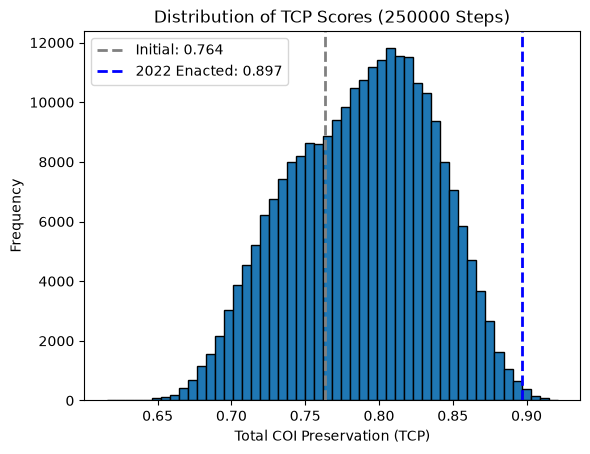

In [74]:
# hist: tcp scores distribution
plt.hist(tcp_scores, bins=50, edgecolor="black")
initial_score = initial_partition["tcp_score"]
score_2021 = enacted_2021["tcp_score"]

plt.axvline(
    initial_score,
    color="grey",
    linestyle="dashed",
    linewidth=2,
    label=f"Initial: {initial_score:.3f}",
)

plt.axvline(
    score_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: {score_2021:.3f}",
)


plt.title(f"Distribution of TCP Scores ({MARKOV_STEPS} Steps)")
plt.xlabel("Total COI Preservation (TCP)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


#average_tcp = sum(tcp_scores)/len(tcp_scores)
#print(average_tcp)

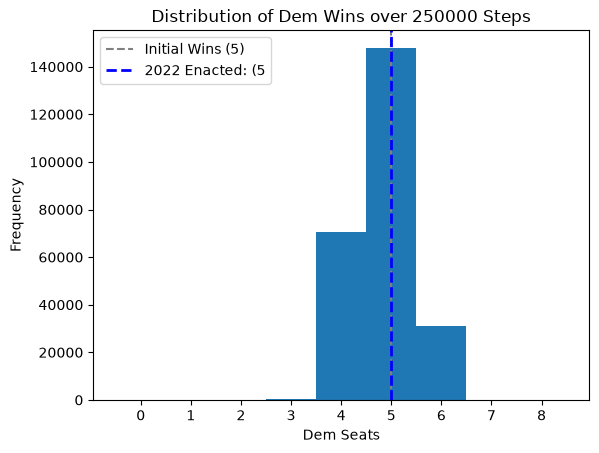

In [75]:
# hist: dem seats distribution
n_districts = len(initial_partition.parts)
plt.hist(
    dem_wins_count, 
    bins=np.arange(-0.5, n_districts + 1.5, 1)
    )
plt.xticks(range(n_districts + 1))
plt.xlabel("Dem Seats")
plt.ylabel("Frequency")
plt.title(f"Distribution of Dem Wins over {MARKOV_STEPS} Steps")

# initial wins line
initial_wins = count_dem_wins(initial_partition)
wins_2021 = count_dem_wins(enacted_2021)

plt.axvline(
    x=initial_wins, 
    color='grey', 
    linestyle='dashed', 
    label=f'Initial Wins ({initial_wins})')

plt.axvline(
    x = wins_2021,
    color="blue",
    linestyle="dashed",
    linewidth=2,
    label=f"2022 Enacted: ({wins_2021}",
)

plt.legend()
plt.show()

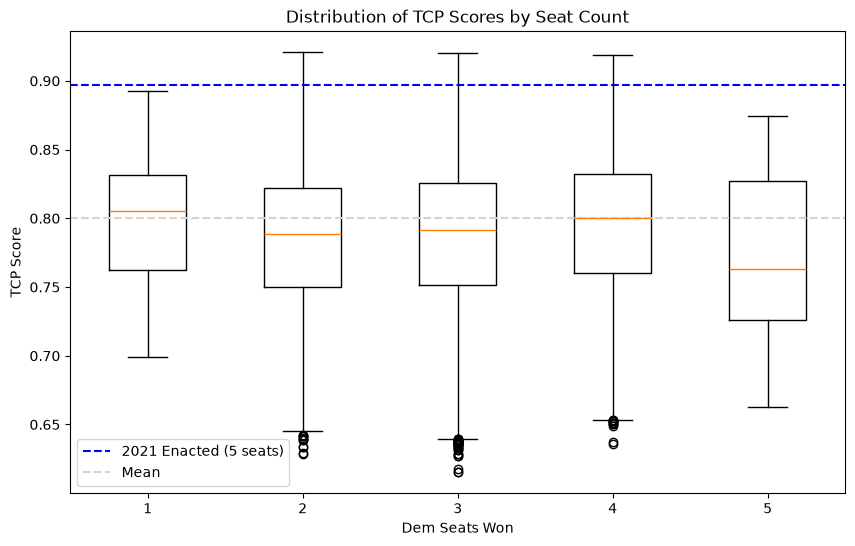

In [76]:
seats_with_data = [s for s in range(9) if len(tcp_scores_by_seats[s]) > 0]
data_to_plot = [tcp_scores_by_seats[s] for s in seats_with_data]

plt.figure(figsize=(10, 6))
plt.boxplot(data_to_plot)
plt.axhline(score_2021, color="blue", linestyle="dashed", label=f"2021 Enacted ({wins_2021} seats)")
plt.axhline(DESIRED_TCP, color="lightgrey", linestyle="dashed", label="Mean")
plt.xlabel("Dem Seats Won")
plt.ylabel("TCP Score")
plt.title("Distribution of TCP Scores by Seat Count")
plt.legend()
plt.show()

plotting most preserved map:
tcp score: 0.921
cut edges: 561
dem seats won: 4/8


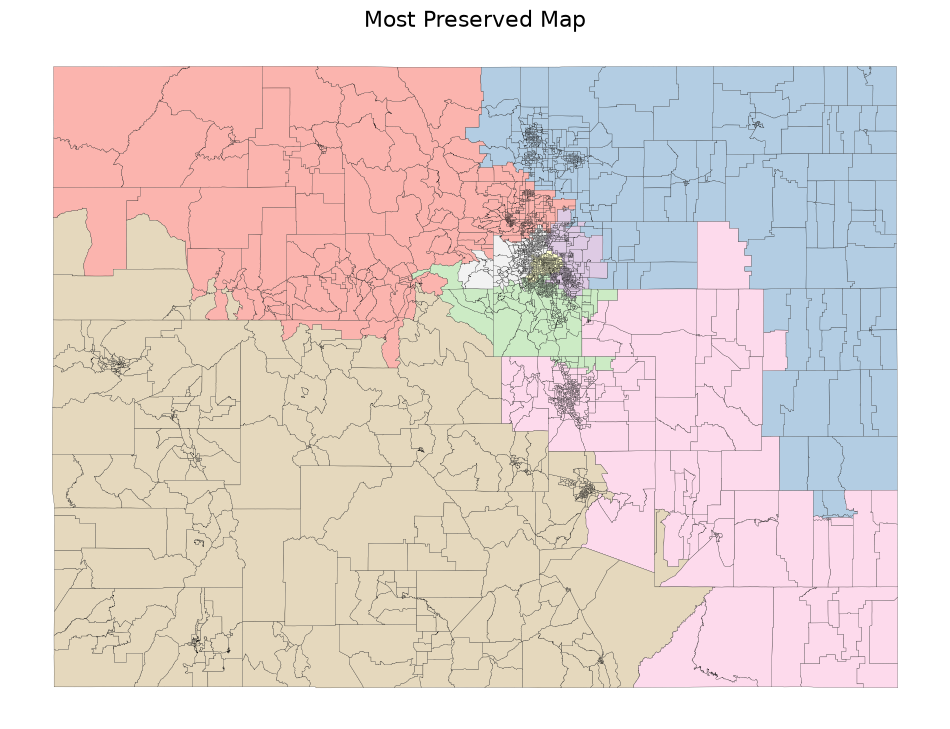

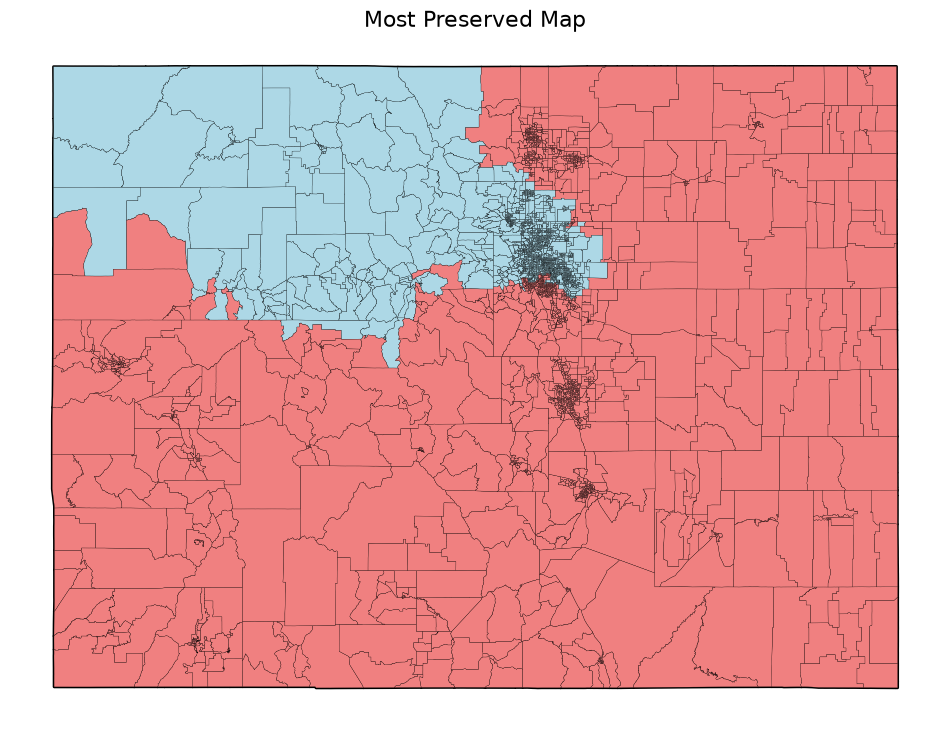

plotting least preserved map:
tcp score: 0.615
cut edges: 740
dem seats won: 5/8


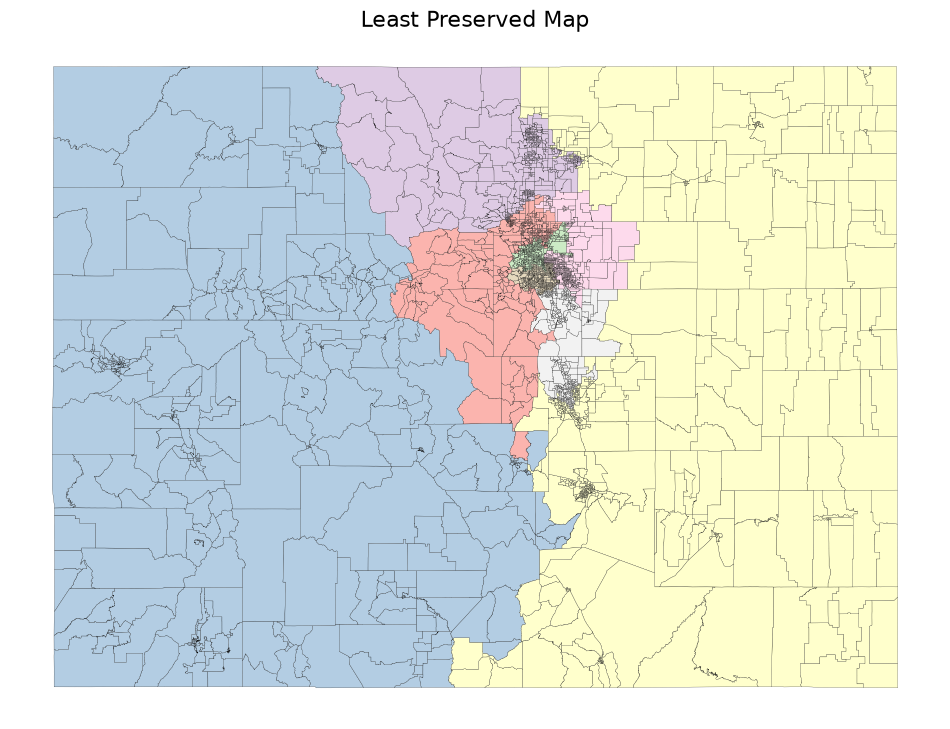

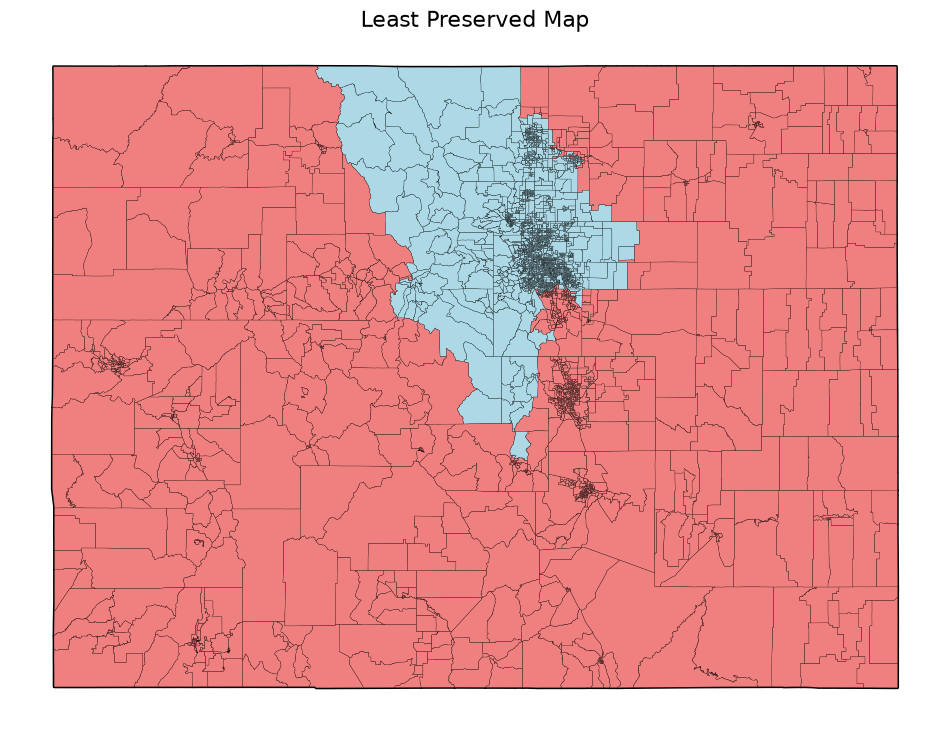

plotting best max representation map:
tcp score: 0.874
cut edges: 576
dem seats won: 7/8


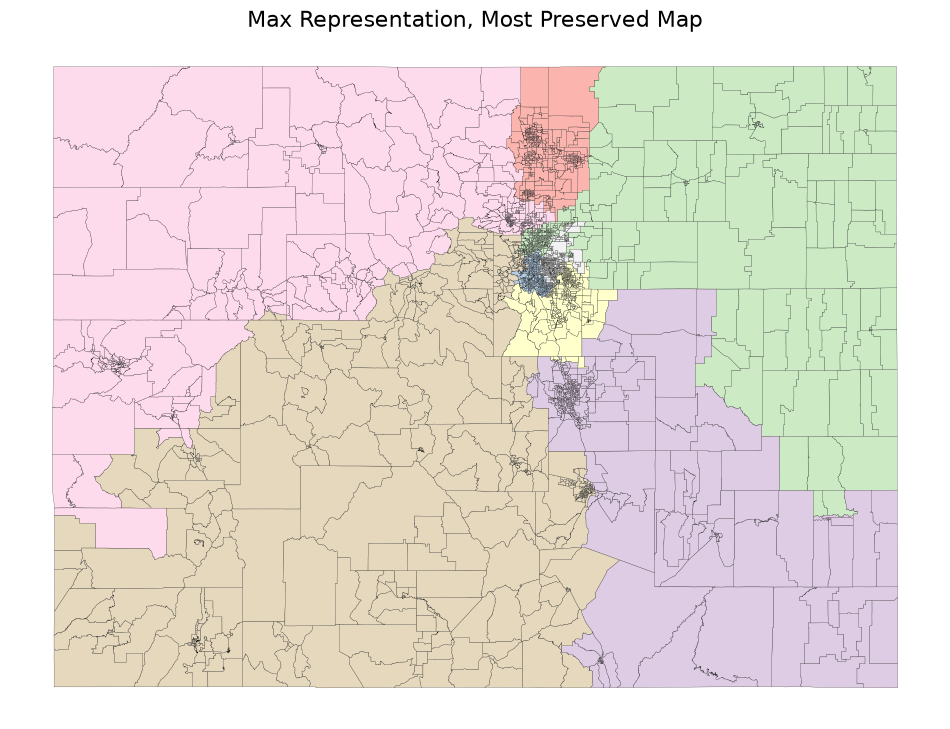

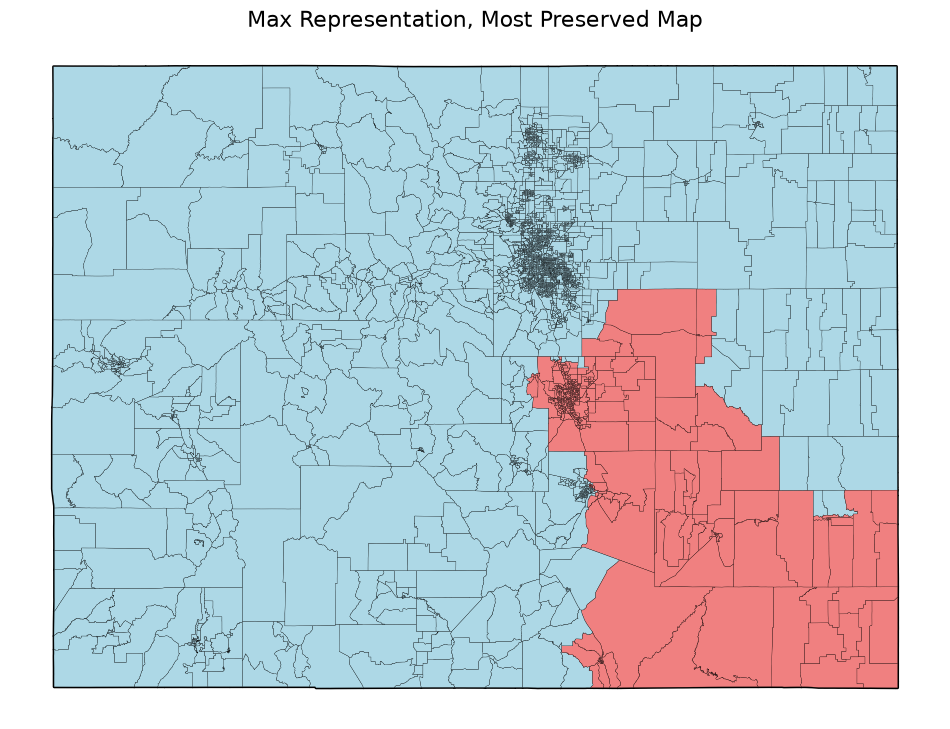

In [77]:

print("plotting most preserved map:")
print(f"tcp score: {best_map['tcp_score']:.3f}")
print(f"cut edges: {len(best_map['cut_edges'])}")
print(f"dem seats won: {best_map['dem_wins']}/8")
plot_partition(best_map, vtds, cois, 'Most Preserved Map')
plot_partition_party(best_map, vtds, cois, 'Most Preserved Map')


print("plotting least preserved map:")
print(f"tcp score: {worst_map['tcp_score']:.3f}")
print(f"cut edges: {len(worst_map['cut_edges'])}")
print(f"dem seats won: {worst_map['dem_wins']}/8")
plot_partition(worst_map, vtds, cois, 'Least Preserved Map')
plot_partition_party(worst_map, vtds, cois, 'Least Preserved Map')

print("plotting best max representation map:")
print(f"tcp score: {overall_best_map['tcp_score']:.3f}")
print(f"cut edges: {len(overall_best_map['cut_edges'])}")
print(f"dem seats won: {overall_best_map['dem_wins']}/8")
plot_partition(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')
plot_partition_party(overall_best_map, vtds, cois, 'Max Representation, Most Preserved Map')



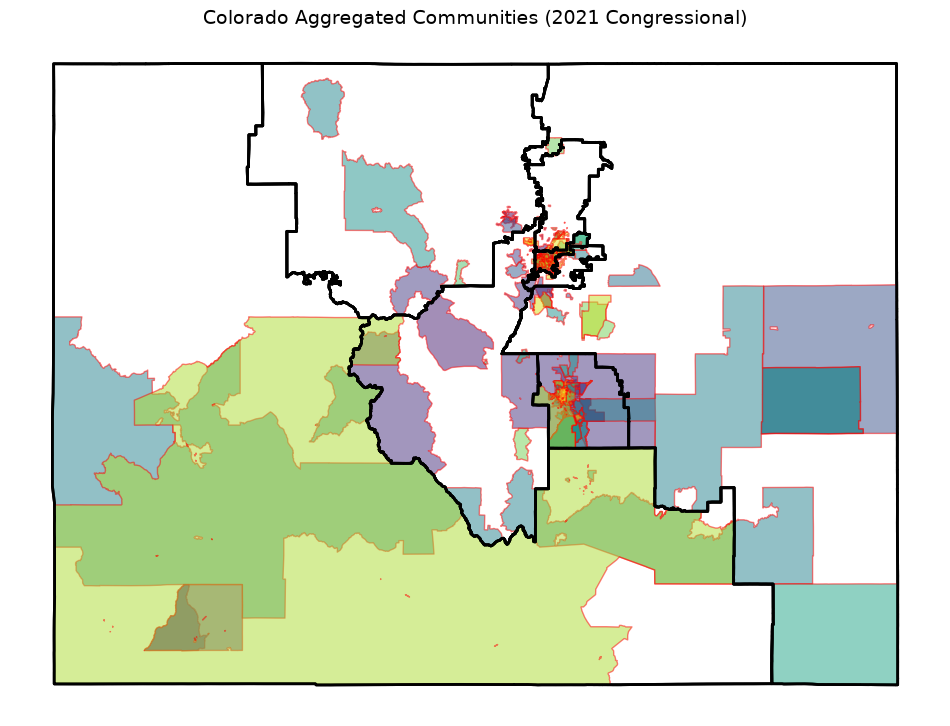

In [78]:
fig, ax = plt.subplots(figsize=(12, 10))

congressional_2021.plot(ax=ax, edgecolor='black', color='white',linewidth=2)
cois.plot(ax=ax, cmap="viridis",edgecolor="red", alpha=0.5)
congressional_2021.plot(ax=ax, facecolor='none', linewidth=2)

ax.set_title("Colorado Aggregated Communities (2021 Congressional)", fontsize=14)
ax.axis("off")
plt.show()